# 【介護DX提案】認知症リスク検知と介入優先度判定モデル
## 結論（サマリー）

本分析では、認知症リスクの早期検知と介入優先度判定を目的とし、
機械学習を用いた意思決定支援モデルを構築した。

特に、閾値調整により見逃し（False Negative）を抑制し、
MMSEと組み合わせた段階的な介入ルールを設計することで、
「検知」と「対応」を一体化した実務モデルを実現した。

本モデルにより、限られた人的リソースの中でも
優先的に対応すべき利用者を明確化し、
現場の意思決定負荷軽減に寄与する。

また、リスクに基づく介入判断を標準化し、
意思決定を再現可能なプロセスとして定義した。


## 背景

本分析では、定員30名規模のナーシングホームを想定する。

介護現場では、限られた職員数の中で、
利用者の状態変化を早期に把握し、適切な介入判断を行う必要がある。

しかし、現場判断は経験や主観に依存しやすく、
対応のばらつきや見逃しが生じる可能性がある。

そこで、本分析では、認知症リスクを数値化し、
介入候補を客観的に抽出する意思決定支援モデルを構築する。

## 本分析の構成

本分析では、以下の2つのモデルを構築した。

1. 高精度モデル（Kaggleデータを用いた検証モデル）
2. 現場実用モデル（現場で取得可能なデータを想定した簡易モデル）

前者では予測精度を重視し、
後者では現場での運用可能性を重視した設計とした。

## 本分析の目的

本分析の目的は、認知症リスクの早期検知と介入優先度判定を通じて、
介護現場における意思決定を支援することである。

単なる予測精度の向上ではなく、
限られた人的リソースの中で、誰を重点的に観察・支援すべきかを判断する仕組みの設計を重視する。

## データ概要

- データ数：2149件
- 特徴量：年齢、生活習慣、認知機能など
- 目的変数：Diagnosis（0: 健常、1: アルツハイマー）

In [ ]:
#ライブラリ & データ読み込み
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="darkgrid")

df = pd.read_csv("alzheimers_disease_data.csv")

## 前処理
不要なカラムを削除し、モデル学習の準備を行う

In [ ]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Gender', 'Ethnicity', 'EducationLevel'], drop_first=True)

In [ ]:
#不要なカラムの削除
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']
#モデル学習の準備
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# モデル①：高精度モデル（Kaggleベース）
Random Forestを用いて分類モデルを構築する

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 評価方針

交差検証およびテストデータによりモデル性能を評価した。

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    RandomForestClassifier(random_state=42),
    X_train, y_train,
    cv=cv,
    scoring=["accuracy", "recall", "precision", "f1", "roc_auc"],
    return_train_score=False
)

cv_summary = pd.DataFrame(cv_results)
print(cv_summary)

print("=== 交差検証の平均評価 ===")
print("Accuracy :", cv_summary["test_accuracy"].mean())
print("Recall   :", cv_summary["test_recall"].mean())
print("Precision:", cv_summary["test_precision"].mean())
print("F1-score :", cv_summary["test_f1"].mean())
print("ROC-AUC  :", cv_summary["test_roc_auc"].mean())

   fit_time  score_time  test_accuracy  test_recall  test_precision   test_f1  \
0  0.564590    0.046227       0.938953     0.859504        0.962963  0.908297   
1  0.528282    0.034619       0.901163     0.801653        0.906542  0.850877   
2  0.537729    0.035593       0.936047     0.852459        0.962963  0.904348   
3  0.541609    0.035555       0.927326     0.836066        0.953271  0.890830   
4  0.550555    0.040338       0.956268     0.900826        0.973214  0.935622   

   test_roc_auc  
0      0.966497  
1      0.933736  
2      0.950838  
3      0.938303  
4      0.972005  
=== 交差検証の平均評価 ===
Accuracy : 0.9319513187334735
Recall   : 0.850101612247663
Precision: 0.9517906591504722
F1-score : 0.8979947948441129
ROC-AUC  : 0.9522759467248652


### 交差検証結果の解釈

5分割交差検証の結果、Accuracyは約0.93、Recallは約0.85となり、
モデルは一定の識別性能を示した。

一方で、Recallが約0.85であることから、
実際の陽性者の一部を見逃す可能性が残る。

医療・介護現場では見逃しが重大なリスクとなるため、
後続では閾値調整によりRecallの向上を図る。

## 確率出力の信頼性向上（キャリブレーション）

RandomForestが出力する予測確率は、そのままでは実際の発生確率と
必ずしも一致しない場合がある。

本分析では、この確率出力をより解釈しやすい値に補正するため、
キャリブレーション（予測確率を実際の発生率に近づける補正）を実施した。




=== 確率出力の平均比較 ===
補正前: 0.35309302325581393
補正後: 0.3462766357560447


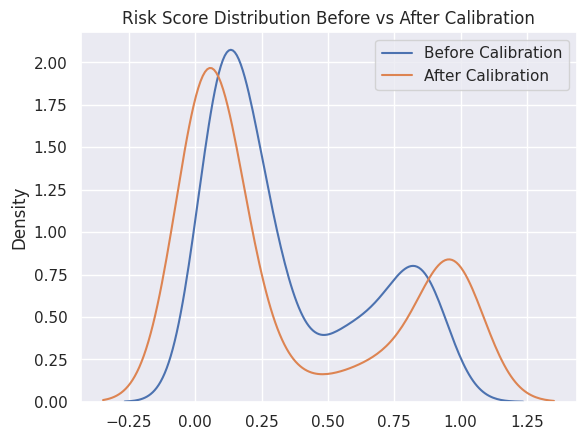

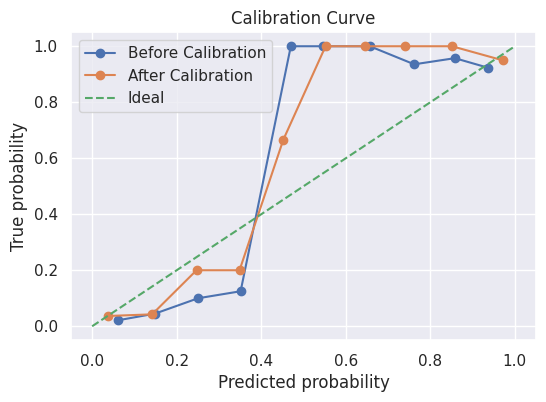

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# 補正前の確率
y_proba_raw = model_rf.predict_proba(X_test)[:, 1]

# キャリブレーション済みモデル
calibrated_model = CalibratedClassifierCV(
    RandomForestClassifier(random_state=42),
    method="sigmoid",
    cv=3
)
calibrated_model.fit(X_train, y_train)

# 補正後の確率
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

print("=== 確率出力の平均比較 ===")
print("補正前:", y_proba_raw.mean())
print("補正後:", y_proba.mean())

# 確率分布の比較
sns.kdeplot(y_proba_raw, label="Before Calibration")
sns.kdeplot(y_proba, label="After Calibration")
plt.legend()
plt.title("Risk Score Distribution Before vs After Calibration")
plt.show()

# Calibration Curve
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6, 4))
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Before Calibration")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="After Calibration")
plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import brier_score_loss

print("=== Brier Score ===")
print("Before:", brier_score_loss(y_test, y_proba_raw))
print("After :", brier_score_loss(y_test, y_proba))

=== Brier Score ===
Before: 0.07865697674418606
After : 0.05413594468074893


## キャリブレーション結果の解釈

キャリブレーションにより、予測確率は全体としてわずかに慎重な方向へ補正された。

また、Brier Scoreは0.078から0.054へと改善しており、
確率予測の精度が向上したことが確認された。

以上より、本分析ではキャリブレーション後の確率を
risk_scoreとして採用する。

## モデル評価

モデルの基本性能を確認し、後続の閾値調整の判断基準とする。

In [ ]:
y_pred = model_rf.predict(X_test)

print("=== RandomForest 標準予測（閾値0.5相当）===")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# キャリブレーション後の確率を用いた0.5閾値評価
y_pred_cal_05 = (y_proba >= 0.5).astype(int)

print("=== キャリブ後（閾値0.5）===")
print(classification_report(y_test, y_pred_cal_05))
print(confusion_matrix(y_test, y_pred_cal_05))

=== RandomForest 標準予測（閾値0.5相当）===
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       277
           1       0.96      0.86      0.91       153

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430

[[272   5]
 [ 22 131]]
=== キャリブ後（閾値0.5）===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       277
           1       0.96      0.90      0.93       153

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430

[[272   5]
 [ 16 137]]


### 評価の解釈

Recallは、実際の陽性者をどれだけ見逃さずに検知できたかを示す指標である。

本分析では、見逃しによるリスクを重視し、
PrecisionよりもRecallを優先する方針とした。

そのため、後続ではキャリブレーション後の確率を用いて
閾値調整を行う。


##特徴量の重要度（Feature Importance）の可視化

/tmp/ipykernel_12883/513007657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


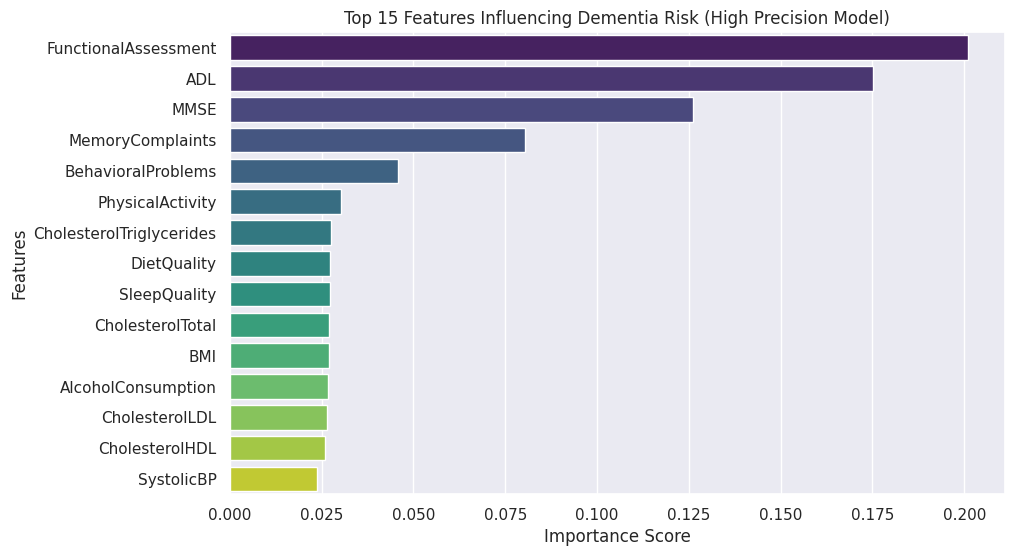

【コンサル視点の考察】
重要度上位にMMSEやADL、FunctionalAssessmentが並んでいることから、客観的な評価指標がリスク判定の核となっています。
現場運用では、これらの数値に変化があった利用者を自動的にリストアップする仕組みが有効です。


In [ ]:
# === 追加コード：特徴量の重要度可視化 ===
import matplotlib.pyplot as plt

# 特徴量重要度の取得
importances = model_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Features Influencing Dementia Risk (High Precision Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("【コンサル視点の考察】")
print("重要度上位にMMSEやADL、FunctionalAssessmentが並んでいることから、客観的な評価指標がリスク判定の核となっています。")
print("現場運用では、これらの数値に変化があった利用者を自動的にリストアップする仕組みが有効です。")

## 特徴量重要度の解釈（現場知見との統合）

MMSE、ADL、FunctionalAssessmentが上位に位置しており、
認知機能および生活機能の低下がリスク判定の主要因であることを確認した。

これは介護現場の実感とも一致しており、
本モデルが実務的に妥当な特徴を捉えていると考えられる。

一方で、一部の指標は単純な因果関係では説明できないため、
本分析では「関連要因」として解釈する。


## 閾値調整の方針

Recallを一定水準以上に保ちながら、
Precisionとのバランスも考慮して閾値を選定する。

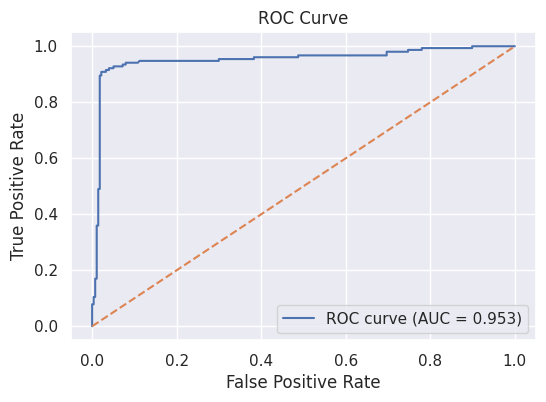

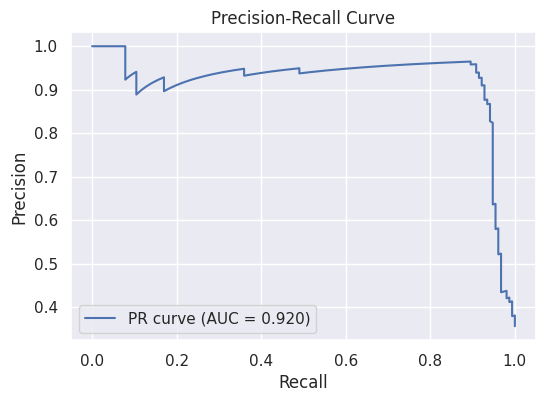

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### ROC・PR曲線の解釈

Recallを高めるほどPrecisionが低下する傾向が確認された。

In [ ]:
threshold_list = np.arange(0.1, 0.9, 0.05)

rows = []
for th in threshold_list:
    y_pred_th = (y_proba >= th).astype(int)
    report = classification_report(y_test, y_pred_th, output_dict=True)
    rows.append({
        "threshold": round(th, 2),
        "accuracy": report["accuracy"],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"]
    })

threshold_df = pd.DataFrame(rows)

print("=== 閾値ごとの評価一覧 ===")
display(threshold_df.round(3))

# Recall制約付き最適閾値
candidate_df = threshold_df[threshold_df["recall_1"] >= 0.85].copy()
best_row = candidate_df.sort_values("f1_1", ascending=False).head(1)

print("=== Recall制約付き最適閾値 ===")
display(best_row.round(3))

focus_df = threshold_df[threshold_df["threshold"].round(2).isin([0.35, 0.40])].copy()
focus_df = focus_df[["threshold", "precision_1", "recall_1", "f1_1", "accuracy"]]

print("=== 注目する閾値の比較 ===")
display(focus_df.round(3))

=== 閾値ごとの評価一覧 ===


,threshold,accuracy,precision_1,recall_1,f1_1
0,0.10,0.826,0.684,0.948,0.795
1,0.15,0.891,0.788,0.948,0.861
2,0.20,0.926,0.867,0.935,0.899
3,0.25,0.940,0.904,0.928,0.916
4,0.30,0.947,0.933,0.915,0.924
5,0.35,0.949,0.946,0.908,0.927
6,0.40,0.953,0.959,0.908,0.933
7,0.45,0.949,0.958,0.895,0.926
8,0.50,0.951,0.965,0.895,0.929
9,0.55,0.940,0.964,0.863,0.910


=== Recall制約付き最適閾値 ===


,threshold,accuracy,precision_1,recall_1,f1_1
6,0.4,0.953,0.959,0.908,0.933


=== 注目する閾値の比較 ===


,threshold,precision_1,recall_1,f1_1,accuracy
5,0.35,0.946,0.908,0.927,0.949
6,0.40,0.959,0.908,0.933,0.953


### 閾値比較の結果

キャリブレーション後の確率に基づいて複数の閾値を比較した結果、
Recallが0.85以上となる候補の中では、
F1-score（PrecisionとRecallのバランスを表す指標）が最も高い閾値が採用候補となった。

本分析では、見逃し防止を優先しつつ、
Precisionとのバランスも確保する観点から、
この条件を満たす最良の閾値を最終採用値とした。

また、代表的な候補である0.35と0.40も比較することで、
採用閾値の妥当性を確認した。


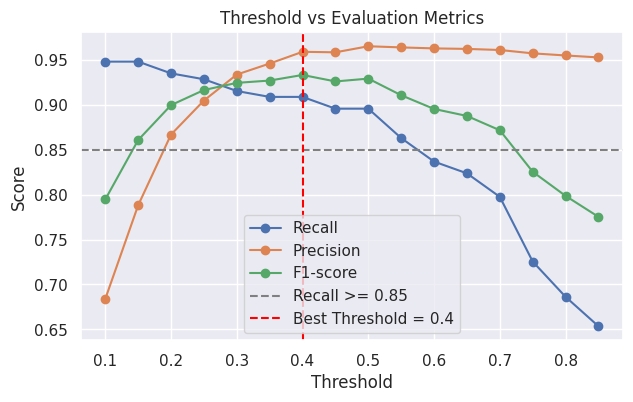

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(threshold_df["threshold"], threshold_df["recall_1"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["precision_1"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["f1_1"], marker="o", label="F1-score")

# Recall制約ライン
plt.axhline(y=0.85, linestyle="--", color="gray", label="Recall >= 0.85")

# 最適閾値
best_threshold = best_row["threshold"].values[0]
plt.axvline(x=best_threshold, linestyle="--", color="red", label=f"Best Threshold = {best_threshold}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Evaluation Metrics")
plt.legend()
plt.show()

## 閾値の決定

本分析では、見逃し防止の観点からRecallを重視し、
Recallが0.85以上となる閾値を候補とした。

その中でF1-scoreが最大となる閾値を最終採用とした。

また、代表的な候補である0.35および0.40と比較した結果、
採用閾値はRecallを確保しつつ、
Precisionとのバランスにも優れていることが確認された。

In [ ]:
SELECTED_THRESHOLD = best_row["threshold"].values[0]
print("採用閾値:", SELECTED_THRESHOLD)

# 採用閾値での最終予測
y_pred_selected = (y_proba >= SELECTED_THRESHOLD).astype(int)

print("=== 採用閾値での分類結果 ===")
print(classification_report(y_test, y_pred_selected))
print(confusion_matrix(y_test, y_pred_selected))

採用閾値: 0.4
=== 採用閾値での分類結果 ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       277
           1       0.96      0.91      0.93       153

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430

[[271   6]
 [ 14 139]]


## 採用閾値での最終評価

採用閾値に基づいて再評価した結果、
見逃し防止と誤検知抑制のバランスを確認した。

この結果を、後続のリスク分類および介入判断ルールに用いる。

## リスクスコアの算出
各利用者のアルツハイマー発症確率を算出する

count    430.000000
mean       0.346277
std        0.398595
min        0.008001
25%        0.029659
50%        0.097891
75%        0.813347
max        0.996657
Name: risk_score, dtype: float64


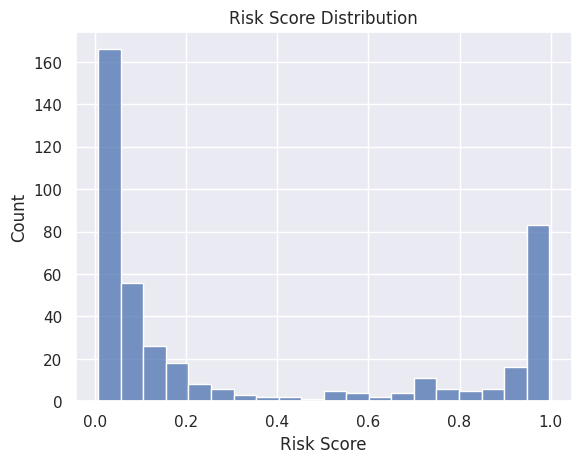

In [ ]:
risk_df = X_test.copy()
risk_df["true_label"] = y_test.values
risk_df["risk_score"] = y_proba

print(risk_df["risk_score"].describe())

sns.histplot(risk_df["risk_score"], bins=20)
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.title("Risk Score Distribution")
plt.show()

## リスクスコアの意味

risk_scoreは、各利用者がアルツハイマーである確率を示す指標である。

このスコアにより、従来は経験に依存していたリスク判断を数値化し、
介入対象の選定を客観的に行うことが可能となる。

## 意思決定ルールの設計

本分析では、以下の2段階で意思決定を行う。

1. 見逃し防止のための採用閾値（SELECTED_THRESHOLD）
2. 優先対応対象を明確にするための高リスク閾値（HIGH_RISK_THRESHOLD）


## リスク分類

risk_scoreに基づいて、利用者をHigh・Medium・Lowの3段階に分類する。  


SELECTED_THRESHOLDは評価指標に基づいて決定した閾値であり、
HIGH_RISK_THRESHOLDは実務上の優先対応ラインとして設定した運用基準である。

したがって、Mediumは「介入候補」、
Highは「より優先的な対応候補」として解釈する。


In [ ]:
# ===== 閾値の設定 =====
HIGH_RISK_THRESHOLD = 0.7   # 優先介入ライン

print("採用閾値（見逃し防止）:", SELECTED_THRESHOLD)
print("高リスク閾値（優先介入）:", HIGH_RISK_THRESHOLD)

def risk_level(score):
    if score >= HIGH_RISK_THRESHOLD:
        return "High"
    elif score >= SELECTED_THRESHOLD:
        return "Medium"
    else:
        return "Low"

risk_df["risk_level"] = risk_df["risk_score"].apply(risk_level)

print("=== リスクレベル分布 ===")
print(risk_df["risk_level"].value_counts())

採用閾値（見逃し防止）: 0.4
高リスク閾値（優先介入）: 0.7
=== リスクレベル分布 ===
risk_level
Low       285
High      127
Medium     18
Name: count, dtype: int64


## 高リスク群の特徴分析

特徴分析は訓練データを用いて実施した。

これは評価データの情報利用による過大評価を防ぐためである。

In [ ]:
# 訓練データを使った特徴分析
train_df = X_train.copy()
train_df["Diagnosis"] = y_train.values

# 訓練データに対する予測確率を算出
train_proba = calibrated_model.predict_proba(X_train)[:, 1]
train_df["risk_score"] = train_proba

# モデルが高リスクと判定した群を抽出
high_risk_train = train_df[train_df["risk_score"] >= SELECTED_THRESHOLD]

# 全体平均との差を比較
compare_df = pd.DataFrame({
    "all_mean": train_df.drop(columns=["Diagnosis", "risk_score"]).mean(),
    "high_risk_mean": high_risk_train.drop(columns=["Diagnosis", "risk_score"]).mean()
})

compare_df["difference"] = compare_df["high_risk_mean"] - compare_df["all_mean"]
compare_sorted = compare_df.sort_values(by="difference")

print("=== 高リスク群の人数 ===")
print(len(high_risk_train))

print("=== 高リスク群で全体平均より低い項目 ===")
display(compare_sorted.head(10))

print("=== 高リスク群で全体平均より高い項目 ===")
display(compare_sorted.tail(10))

=== 高リスク群の人数 ===
617
=== 高リスク群で全体平均より低い項目 ===


,all_mean,high_risk_mean,difference
MMSE,14.737994,12.060494,-2.677500
FunctionalAssessment,5.069688,3.565974,-1.503715
ADL,4.970744,3.602201,-1.368543
SystolicBP,134.272833,133.098865,-1.173968
Age,74.960442,74.726094,-0.234348
CholesterolLDL,124.460516,124.247657,-0.212858
SleepQuality,7.038044,6.915117,-0.122927
PhysicalActivity,4.942195,4.878786,-0.063409
Ethnicity_1,0.212914,0.192869,-0.020046
FamilyHistoryAlzheimers,0.249564,0.230146,-0.019418


=== 高リスク群で全体平均より高い項目 ===


,all_mean,high_risk_mean,difference
Ethnicity_2,0.095986,0.105348,0.009362
Hypertension,0.152414,0.163695,0.011281
DietQuality,4.972312,5.066847,0.094536
BehavioralProblems,0.156486,0.256078,0.099591
MemoryComplaints,0.205934,0.363047,0.157113
CholesterolTotal,224.902755,225.066071,0.163316
BMI,27.687408,27.905913,0.218505
DiastolicBP,89.436300,90.000000,0.563700
CholesterolHDL,58.953705,60.406042,1.452337
CholesterolTriglycerides,229.276945,233.920469,4.643524


### 高リスク群の特徴に関する考察

MMSE、ADL、FunctionalAssessmentにおいて大きな差が確認された。

これらはいずれも認知機能および生活機能を表す指標であり、
本モデルはこれらの低下を主要な判断材料としている。

また、MemoryComplaintsやBehavioralProblemsも高リスク群で増加しており、
主観的な症状や行動変化もリスク判定に影響していると考えられる。

以上より、本モデルは
「認知機能・生活機能の低下」を中心に
高リスク判定を行っていると解釈できる。

## 介入シミュレーション

本シミュレーションでは、ADLおよびFunctionalAssessmentを一律に改善させた場合の
リスクスコア変化を検証した。

その結果、リスクスコアは全体として低下し、
特に高リスク群において大きな改善が確認された。

ただし、本結果は仮定に基づくものであり、
実際の介入効果を示すものではない。

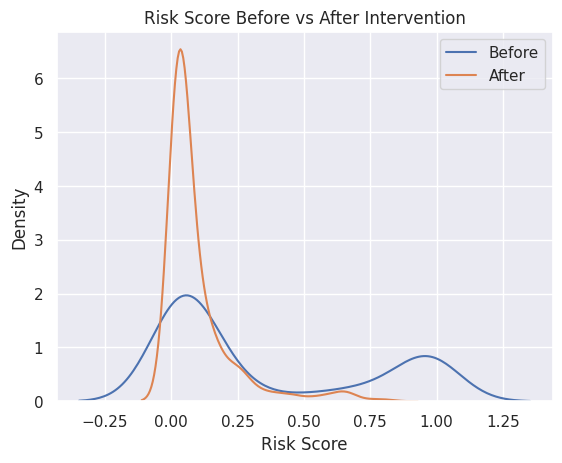

介入前平均: 0.3462766357560447
介入後平均: 0.09633566230563252
平均変化: -0.24994097345041222


In [ ]:
sim_df = X_test.copy()

sim_df["ADL"] += 5
sim_df["FunctionalAssessment"] += 5

sim_pred = calibrated_model.predict_proba(sim_df)[:, 1]

risk_df["sim_risk_score"] = sim_pred
risk_df["risk_change"] = risk_df["sim_risk_score"] - risk_df["risk_score"]

sns.kdeplot(risk_df["risk_score"], label="Before")
sns.kdeplot(risk_df["sim_risk_score"], label="After")
plt.xlabel("Risk Score")
plt.ylabel("Density")
plt.legend()
plt.title("Risk Score Before vs After Intervention")
plt.show()

print("介入前平均:", risk_df["risk_score"].mean())
print("介入後平均:", risk_df["sim_risk_score"].mean())
print("平均変化:", risk_df["risk_change"].mean())

### 介入シミュレーション結果の解釈

介入後はrisk_scoreの分布が低リスク側へ移動し、
平均risk_scoreも0.346から0.096へ低下した。

平均変化量は-0.250であり、
生活機能の改善を仮定した場合、モデル上では全体的にリスクが低下する傾向が確認された。

## 介入優先度の判定

risk_scoreとMMSEを組み合わせることで、
「リスクの高さ」と「認知機能の状態」の両面から介入優先度を判定した。

これにより、単なるリスク検知にとどまらず、
実務上の意思決定に直接利用可能な形へと落とし込んだ。

In [ ]:
def intervention_decision(row):
    # 高リスクかつ認知機能低下あり → 優先介入
    if row["risk_score"] >= HIGH_RISK_THRESHOLD and row["MMSE"] < 15:
        return "優先介入"

    # 採用閾値以上 → 介入
    elif row["risk_score"] >= SELECTED_THRESHOLD:
        return "介入"

    # それ未満 → 非介入
    else:
        return "非介入"

risk_df["intervention_level"] = risk_df.apply(intervention_decision, axis=1)

## 介入効果のまとめ

In [ ]:
summary = risk_df.groupby("intervention_level").agg({
    "risk_score": "mean",
    "sim_risk_score": "mean",
    "risk_change": "mean"
})
print("=== 介入レベル別の要約 ===")
display(summary)

=== 介入レベル別の要約 ===


,risk_score,sim_risk_score,risk_change
intervention_level,,,
介入,0.809961,0.204396,-0.605565
優先介入,0.933954,0.145091,-0.788862
非介入,0.072082,0.059669,-0.012412


## 介入効果の解釈

介入レベルごとにリスク変化に明確な差が確認された。

特に優先介入群では大きなリスク低下が見られ、
高リスク者に対する介入の有効性が示唆された。

これにより、本モデルは単なるリスク分類にとどまらず、
「どの対象に介入すべきか」を判断する指標として機能する。

## 期待される業務改善効果

高リスク者を早期に抽出し、
限られた人的リソースを重点的な観察・支援に振り向けることが可能となる。

定員30名規模の施設であっても、
数名単位の見逃し削減は、重症化予防や介護負担の増加抑制につながる可能性がある。

以上より、本モデルはケア品質の向上だけでなく、
人的リソースの最適配分にも寄与する。

## ビジネスインパクト（ROIの観点）

本モデルは単なる予測精度の向上ではなく、現場および経営に対して以下の価値を提供する。

### ① Value to Patient（利用者価値）
- 認知機能低下の早期検知により、適切な介入を前倒しで実施可能  
- 生活機能の維持（QOL維持）に寄与  

### ② Value to Staff（職員価値）
- リスク評価の標準化により、判断のばらつきを抑制  
- 優先度が可視化されることで、心理的負担および業務負荷を軽減  

### ③ Value to Business（経営価値）
- 重症化予防により、入院・退所リスクを低減し稼働率を安定化  
- データ活用によるDX推進により、施設価値・ブランドの向上に寄与  

## 実務導入時の運用プロセス

本モデルを現場に定着させるための標準業務フローを以下のように定義する。




##ビジネスプロセス全体像

| ステップ | プロセス内容 | AIの役割 / 出力項目 |
|:--|:--|:--|
| **1. データ入力** | 定期評価（ADL / MMSE）を既存システムへ入力<br><br> | インプットデータの標準化<br><br> |
| **2. AI解析** | リスクスコアの自動算出<br><br> | 確率に基づいた客観的リスク判定<br><br> |
| **3. リスク分類** | スコアに基づき利用者を3層に自動分類<br><br> | High / Medium / Low のラベル付<br><br> |
| **4. 意思決定** | 専門職による最終介入判断・カンファレンス<br><br> | 優先介入対象のレコメンド<br><br> |
| **5. 介入・評価** | ケアプラン修正と介入効果の記録<br><br> | 継続学習のためのフィードバック<br><br> |

## ビジネスプロセス・アーキテクチャ

Data Input（データ入力）  
→ 月次ADL / MMSE評価をシステムへ入力  

↓  

AI Analysis（AI解析）  
→ リスクスコアを算出  

↓  

Actionable Insight（示唆抽出）  
→ 高リスク者を自動抽出  

↓  

意思決定  
→ 多職種カンファレンスで介入判断  

↓  

介入・評価  
→ ケア実施および効果測定  

↓  

Feedback Loop  
→ 結果をデータに反映し、モデルを継続改善

## リスクレベル別のアクション定義

###  🔴High Risk（高リスク）：優先介入
- ケアマネジャー・看護師による緊急評価を実施  
- 主治医への報告  
- 多職種連携によるケアプランの即時修正  

---

###  🟡Medium Risk（中リスク）：重点モニタリング
- 予防プランの強化（リハビリ頻度の調整等）  
- 次月アセスメントにおいてスコア推移を最重点項目として確認  

---

###  🔵Low Risk（低リスク）：通常ケア
- 現行のケアプランを継続  
- 異常の早期発見に向けた日常的な観察を継続  

---

##  設計の意図：Human-in-the-Loop

AIを最終判断者とするのではなく、専門職がリソースを集中すべき対象を指し示す意思決定支援ツールとして定義する。  
これにより、判断の説明可能性を担保しつつ、人とAIの役割分担を明確化する。

## 倫理的配慮と運用上の考え方

介護の現場においては、利用者に対する対応は本来平等であるべきである。

一方で、実際の現場では職員数や時間といったリソースに制約があり、
すべての利用者に対して同一レベルの観察や対応を行うことは現実的に困難である。

「優先順位づけ」を行うのではなく、
リスクに応じて観察や介入の“強度”を調整するという考え方を採用している。

判断基準を明確にすることで、
現場における暗黙的な判断基準を可視化し、
職員の判断負荷を軽減するとともに、
対応のばらつきを抑制することが期待される。



## モデル②：現場実用モデル

本モデルは、現場で取得可能な最小限のデータに基づき、
即時導入を想定した簡易モデルとして設計した。

高精度モデルを将来的な理想形としつつ、
まずはMVPとして運用可能性を検証し、
現場データの蓄積に応じて段階的に精度向上を図る。

### 使用する特徴量

本モデルでは、実際の介護現場で取得可能な以下の特徴量を使用した。

- ADL_score（生活機能）
- MMSE（認知機能）
- meal_assist（食事介助量）
- toilet_assist（排泄介助量）
- care_level（要介護度）
- staff_rating（スタッフ評価）

In [ ]:
np.random.seed(42)

n = len(df)

df_real = pd.DataFrame({
    "ADL_score": df["ADL"],
    "MMSE": df["MMSE"],
    "meal_assist": np.random.randint(0, 3, n),      # 0:自立 1:一部介助 2:全介助
    "toilet_assist": np.random.randint(0, 3, n),
    "care_level": np.random.randint(1, 6, n),       # 要介護1〜5
    "staff_rating": np.random.randint(1, 6, n),     # 主観評価
    "Diagnosis": df["Diagnosis"]
})

# ADLと介助量の関係を反映（簡易的な現実寄せ）
df_real["meal_assist"] = pd.cut(
    df_real["ADL_score"],
    bins=[0, 3, 6, 10],
    labels=[2, 1, 0]
).astype(int)

df_real["toilet_assist"] = pd.cut(
    df_real["ADL_score"],
    bins=[0, 3, 6, 10],
    labels=[2, 1, 0]
).astype(int)

df_real["care_level"] = pd.cut(
    df_real["ADL_score"],
    bins=[0, 2, 4, 6, 8, 10],
    labels=[5, 4, 3, 2, 1]
).astype(int)

df_real["staff_rating"] = pd.cut(
    df_real["MMSE"],
    bins=[0, 10, 15, 20, 25, 30],
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [ ]:
# ① 特徴量と目的変数
X_real = df_real.drop(columns=["Diagnosis"])
y_real = df_real["Diagnosis"]

# ② データ分割
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

# ③ モデル学習
from sklearn.ensemble import RandomForestClassifier

model_real = RandomForestClassifier(random_state=42)
model_real.fit(X_train_r, y_train_r)

# ④ 予測確率
y_proba_r = model_real.predict_proba(X_test_r)[:, 1]

# ⑤ 閾値ごとの予測
y_pred_05 = (y_proba_r >= 0.5).astype(int)
y_pred_04 = (y_proba_r >= 0.4).astype(int)

# ⑥ 評価
from sklearn.metrics import classification_report, confusion_matrix

print("=== 閾値0.5 ===")
print(classification_report(y_test_r, y_pred_05))
print(confusion_matrix(y_test_r, y_pred_05))

print("\n=== 閾値0.4 ===")
print(classification_report(y_test_r, y_pred_04))
print(confusion_matrix(y_test_r, y_pred_04))

## 閾値調整によるモデル性能の比較

現場実用モデルでは、閾値0.5と0.4を比較した。

閾値を0.4に下げることで、Recallは0.57から0.63へ向上し、
False Negativeは66件から56件へ減少した。

一方で、False Positiveは53件から65件へ増加しており、
見逃し削減と誤検知増加のトレードオフが確認された。

以上より、現場実用モデルでは見逃し防止を重視し、
暫定的に閾値0.4を採用する。

ただし、疑似生成した特徴量を含むため、
実運用には現場データに基づく再検証が必要である。

## 考察

本分析では、高精度モデルと現場実用モデルの2つを構築し、
精度と運用性の両面から認知症リスク検知の可能性を検証した。

高精度モデルでは、ADL・MMSE・FunctionalAssessmentがリスクと強く関連しており、
モデルが臨床的に妥当な特徴を捉えていることを確認した。

また、閾値調整によりRecallを向上させることで、
見逃しを抑えたリスク検知が可能であることが示された。

一方で、閾値を下げることで誤検知が増加するというトレードオフが存在するため、
本分析ではMMSEを併用し、介入優先度を段階的に分類することで対応した。

現場実用モデルにおいても、限られたデータのみで閾値調整を行うことで、
実務上十分に活用可能なリスク検知が実現できることを確認した。

特に「非介入」という判断を明示することで、
過剰な介入を避けつつ利用者の自立を尊重する意思決定を可能にした点に意義がある。

以上より、本モデルは早期検知と介入判断を統合した、
実務的な意思決定支援ツールとして活用可能である。

リスクの可視化から介入判断までを一貫して設計した点により、
これまで経験や勘に依存していた判断プロセスを標準化し、
再現可能な意思決定フローとして定義した。

これにより、判断を個人依存から組織的なプロセスへ転換できる。


## 今後の課題

本モデルは単一時点のデータに基づいており、
利用者の状態変化を十分に捉えられていない。

今後は時系列データを活用することで、
「いつ介入すべきか」という意思決定の高度化が求められる。

また、施設ごとの特性に応じた再学習を行うことで、
実運用への適用精度を高める必要がある。


## 結論

本分析では、認知症リスクの早期検知と介入優先度判定を統合した
意思決定支援モデルを構築した。

閾値調整により見逃しを抑制しつつ、
MMSEを組み合わせた段階的な判断ルールを設計することで、
実務での活用可能性を示した。

今後は実データおよび時系列情報を取り入れることで、
さらなる精度向上と運用性の強化が期待される。